In [1]:
%reload_ext autoreload
%autoreload 2

import os
from os.path import join
from matplotlib.ticker import MaxNLocator
from rocqiomics.personal_utils import load_feature_maps
import matplotlib.pyplot as plt
from monai.transforms import Resize
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import SimpleITK as sitk

BASEPATH = r"C:\Users\ri54995\AppData\Local\Programs\Python\envs\radiomics\Lib\site-packages\rocqiomics\tutorial\tutorial_results"
IMAGESPATH = r'C:\Users\ri54995\AppData\Local\Programs\Python\envs\radiomics\Lib\site-packages\rocqiomics\test_data\Images'
MAPSPATH = join(BASEPATH, 'Feature Maps')

In [3]:

cases = [
    'RGS021425_ph1',
    'RGS021425_ph2',
    'RGS021425_ph3',
]

three_clusters = []
four_clusters = []
five_clusters = []

for case_id in cases:

    fmap_loader = load_feature_maps(
        features_dirpath=BASEPATH,
        feature_classes=[
            'firstorder',
            'ngtdm',
            'gldm'
            ],
        mask_names=['Snickers'],
        timepoints=['d1'],
        modalities=['T2'],
        case_ids=[case_id]
    )


    fmaps = []
    for i, (cid, fmap) in enumerate(fmap_loader):
        fmaps.append(np.transpose(sitk.GetArrayFromImage(fmap), (2,1,0))[:,:,15])

    print(len(fmaps))

    # Suppose you have a 3D image volume and some extra feature maps
    H, W = fmaps[0].shape[0:2]
    D = 1

    # Stack features into (H, W, D, n_features)
    features = np.stack(fmaps, axis=-1)  # shape (H,W,D,3)

    # Build voxel coordinate grid
    zz, yy, xx = np.meshgrid(
        np.arange(D), np.arange(H), np.arange(W), indexing="ij"
    )
    coords = np.stack([yy, xx, zz], axis=-1)  # shape (D,H,W,3)

    # Reshape both coords and features to (num_voxels, dim)
    coords = coords.reshape(-1, 3)
    features = features.reshape(-1, features.shape[-1])

    # Concatenate coords + features
    X = np.concatenate([coords, features], axis=1)  # shape (num_voxels, 3+n)
    # X = features  # shape (num_voxels, 3+n)


    # Optional: scale features so coordinates and intensities are comparable
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # Run KMeans
    k = 4
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    clustered = labels.reshape(H, W, D)
    four_clusters.append(clustered)

    k = 5
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    clustered = labels.reshape(H, W, D)
    five_clusters.append(clustered)


37
37
37


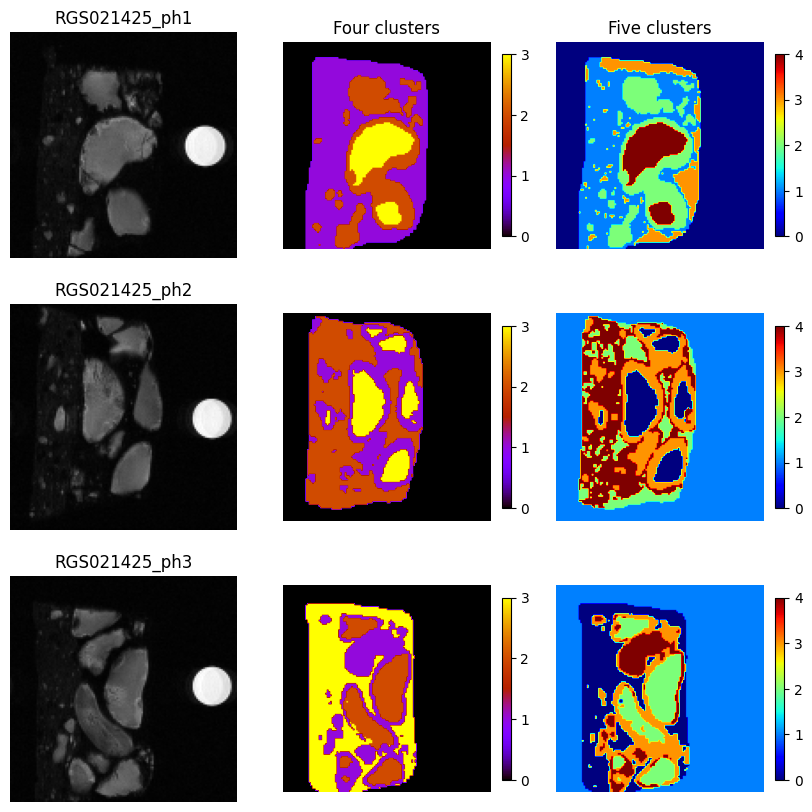

In [4]:
fig, ax = plt.subplots(3,3, figsize=(10,10))

for i in range(len(cases)):

    img_path = join(IMAGESPATH, f"d1_T2_{cases[i]}.nrrd")
 
    img = sitk.GetArrayFromImage(sitk.ReadImage(img_path))
    img = np.transpose(img, (2,1,0))
    img = np.stack([img])
    img = Resize(spatial_size=(128, 128, -1), mode='area')(img).numpy()[0,:,:,19:20]

    ax[i,0].imshow(img[:,:,0], cmap='gray')
    ax[i,0].set_title(cases[i])
    ax[i,0].axis('off')
    
    im1 = ax[i,1].imshow(four_clusters[i][:,:,0], cmap='gnuplot')
    ax[i,1].set_title('Four clusters') if i == 0 else None
    ax[i,1].axis('off')
    cbar = fig.colorbar(im1, ax=ax[i,1], fraction=0.04)
    cbar.ax.yaxis.set_major_locator(MaxNLocator(integer=True))

    im2 = ax[i,2].imshow(five_clusters[i][:,:,0], cmap='jet')
    ax[i,2].set_title('Five clusters') if i == 0 else None
    ax[i,2].axis('off')
    cbar = fig.colorbar(im2, ax=ax[i,2], fraction=0.04)
    cbar.ax.yaxis.set_major_locator(MaxNLocator(integer=True))

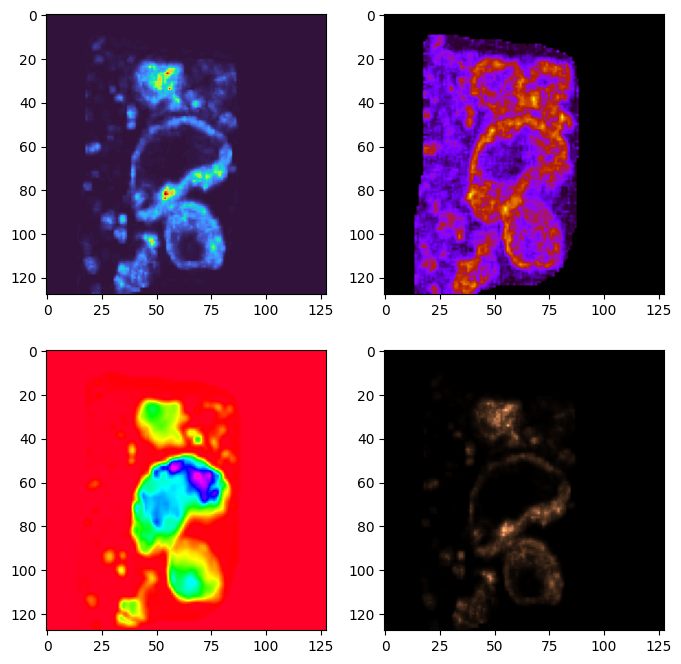

In [5]:
names = [
    'ngtdm_Contrast',
    'gldm_SmallDependenceEmphasis',
    'firstorder_Energy',
    'ngtdm_Contrast'
]

cmaps = [
    'turbo',
    'gnuplot',
    'gist_rainbow',
    'copper'
]
fig, ax = plt.subplots(2,2, figsize=(8,8))

for i in range(4):
    img = sitk.GetArrayFromImage(sitk.ReadImage(join(MAPSPATH, 'RGS021425_ph1', f'd1_T2_Snickers_original_{names[i]}.nrrd')))
    img = np.transpose(img, (2,1,0))


    ax.flatten()[i].imshow(img[:,:,15], cmap=cmaps[i])